# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 8: *Evaluation and Visualization*
##### Version Number: 3.0
---
### Contents  
> 1. *Build Models*
> 2. *Train Models*
> 3. *Generate Predictions*
> 4. *Geospatial Visualization*
> 5. *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios including
- #### Palisades Fire (January 07, 2025)  

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **LightGBM**
---
### Inputs
- `X_scaled`,`y_reduced` ,`details_reduced` - Model testing dataset in full or reduced versions 
- `pal_X`,`pal_y`, `pal_details` Case study data for 2025 predictions
- `best_strategy` best class balancing strategies calculated from module 06
- `model_parameters` optimum model parameters as determined by module 07

---
### Outputs  
- `predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS. 
- **Date range** 01/01/2025 to 01/23/2025.
---
### User Created Dependencies  

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# user built utilities
from src.plot_utils import plot_map

from src.model_utils import apply_balancing

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

from datetime import timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

---
### Global Constants

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

---

### Load Data

In [4]:
X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()  # Load as Series
details = pd.read_csv('../data/processed/details.csv')

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

best_strategy = pd.read_csv('../data/processed/best_strategy.csv')
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

In [5]:
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date
details['Date'] = pd.to_datetime(details['Date']).dt.date

#### Modeling dataset target distribution

In [6]:
y.value_counts()

Target
0    50000
1    50000
2    24818
Name: count, dtype: int64

## 1. Build Models

In [7]:
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

In [8]:

# data was stored as string in dataframe, convert to int for building models
RF_parameters = model_parameters.loc['RandomForest'].dropna().to_dict()
XGB_parameters = model_parameters.loc['XGBoost'].dropna().to_dict()
LGBM_parameters = model_parameters.loc['LGBM'].dropna().to_dict()
# save float data

optimal_learning_rate = XGB_parameters['learning_rate']
optimal_learning_rate_lgbm = LGBM_parameters['learning_rate']


In [9]:
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}


# data was stored as string in dataframe, convert to int for building models
RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
LGBM_parameters = convert_to_int(LGBM_parameters)


# assign floats back to key variables
XGB_parameters['learning_rate'] = optimal_learning_rate
LGBM_parameters['learning_rate'] = optimal_learning_rate_lgbm
LGBM_parameters['verbose'] = -1

In [10]:
display(RF_parameters)
display(XGB_parameters)
display(LGBM_parameters)

{'n_estimators': 100,
 'max_depth': 20,
 'min_samples_split': 2,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'n_estimators': 200,
 'max_depth': 6,
 'objective': 'multi:softmax',
 'num_class': 3,
 'learning_rate': 0.4,
 'verbosity': 0}

{'n_estimators': 150,
 'max_depth': 11,
 'class_weight': 'balanced',
 'learning_rate': 100.0,
 'num_leaves': 255,
 'verbose': -1}

In [11]:
# Build Final tuned models
optimum_xgb_model = xgb.XGBClassifier(**XGB_parameters)
optimum_rf = RandomForestClassifier(**RF_parameters)
optimum_lgbm_model = LGBMClassifier(**LGBM_parameters)

## 2. Train Models

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [13]:
X_train_balanced, y_train_balanced = apply_balancing('RF', best_strategy, X_train, y_train)
optimum_rf.fit(X_train, y_train)

X_train_balanced, y_train_balanced = apply_balancing('LGBM', best_strategy, X_train, y_train)
optimum_lgbm_model.fit(X_train, y_train)

X_train_balanced, y_train_balanced = apply_balancing('XGB', best_strategy, X_train, y_train)
optimum_xgb_model.set_params(verbosity=0)
optimum_xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

## Importance Results

In [14]:
# Create a Series for easy sorting
importances = pd.Series(optimum_rf.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="Random Forest Top 10 Importance")

,Random Forest Top 10 Importance
2-Year Avg Fires,0.054139
Year,0.037762
1000-hour Dead Fuel Moisture,0.027967
slope_mean,0.027363
Palmer Drought Severity Index,0.025788
Solar Radiation 7 Day Avg,0.021294
Solar Radiation,0.017640
elevation_range,0.017346
Daily Maximum Air Temperature 7 Day Avg,0.017172
Energy Release Component,0.017153


In [15]:
# Create a Series for easy sorting
importances = pd.Series(optimum_lgbm_model.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="LGBM Top 10 Importance")

,LGBM Top 10 Importance
2-Year Avg Fires,85
Year,60
Palmer Drought Severity Index,59
Solar Radiation 7 Day Avg,46
1000-hour Dead Fuel Moisture,45
Standardized Precipitation Evapotranspiration Index 180-Day,29
Standardized Precipitation Evapotranspiration Index 90-Day,28
influence_zone,24
Standardized Precipitation Index 30-Day,23
slope_mean,23


In [16]:
# Create a Series for easy sorting
importances = pd.Series( optimum_xgb_model.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="XGB Top 10 Importance")

,XGB Top 10 Importance
total_population,0.107171
dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow,0.076785
slope_mean,0.041714
intermix_zone,0.040091
dominant_section_description_Southern California Mountains and Valleys,0.031294
power_line_density_x_total_housing,0.028271
elevation_range,0.026584
dominant_section_description_Southern California Coast,0.024488
Season_Fall,0.023314
Season_Suumer,0.022938


## Metrics

In [17]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
    print("---- Classification Report ----")
    print(classification_report(y_test, y_pred))
    print("\n")

In [18]:
evaluate_model(optimum_xgb_model, X_test, y_test, "XGBoost")

Evaluation for XGBoost
Accuracy:  0.847
Precision: 0.846
Recall:    0.847
F1 Score:  0.847
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      9968
           1       0.81      0.82      0.82     10053
           2       0.93      0.96      0.95      4943

    accuracy                           0.85     24964
   macro avg       0.86      0.87      0.86     24964
weighted avg       0.85      0.85      0.85     24964





In [19]:
evaluate_model(optimum_rf, X_test, y_test, "Random Forest")

Evaluation for Random Forest
Accuracy:  0.843
Precision: 0.842
Recall:    0.843
F1 Score:  0.842
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      9968
           1       0.82      0.81      0.81     10053
           2       0.91      0.96      0.93      4943

    accuracy                           0.84     24964
   macro avg       0.85      0.86      0.86     24964
weighted avg       0.84      0.84      0.84     24964





In [20]:
evaluate_model(optimum_lgbm_model, X_test, y_test, "LightGBM")

Evaluation for LightGBM
Accuracy:  0.380
Precision: 0.546
Recall:    0.380
F1 Score:  0.357
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.66      0.30      0.42      9968
           1       0.57      0.17      0.26     10053
           2       0.27      0.96      0.42      4943

    accuracy                           0.38     24964
   macro avg       0.50      0.48      0.37     24964
weighted avg       0.55      0.38      0.36     24964





## 3. Generate Predictions

In [21]:
# Palisades Fire (January 2025)
pal_xgb_predictions = pd.DataFrame(optimum_xgb_model.predict(pal_X))
pal_xgb_predictions.value_counts()

0
0    4381
1    1019
2      28
Name: count, dtype: int64

In [22]:
pal_rf_predictions = pd.DataFrame(optimum_rf.predict(pal_X))
pal_rf_predictions.value_counts()

0
0    4559
1     860
2       9
Name: count, dtype: int64

In [23]:
pal_lgbm_predictions = pd.DataFrame(optimum_lgbm_model.predict(pal_X))
pal_lgbm_predictions.value_counts()

0
0    4489
1     887
2      52
Name: count, dtype: int64

### 3.1 Save Predictions for plotting

In [24]:
pal_details = pal_details.copy()

pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
pal_details['Prediction RF']  = pal_rf_predictions[0].values
pal_details['Prediction LGBM']  = pal_lgbm_predictions[0].values

pal_details['Prediction Actual'] = pal_y

#### Identify specific day to plot

In [40]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

#### Define geometries

In [41]:
pal_details['geometry'] = [Point(xy) for xy in zip(pal_details['centroid_easting'], pal_details['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(pal_details , geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

#### Subset data for visualization

In [42]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## 2 Geospatial Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025).

### 2.1 Palisades Predictions 01072025

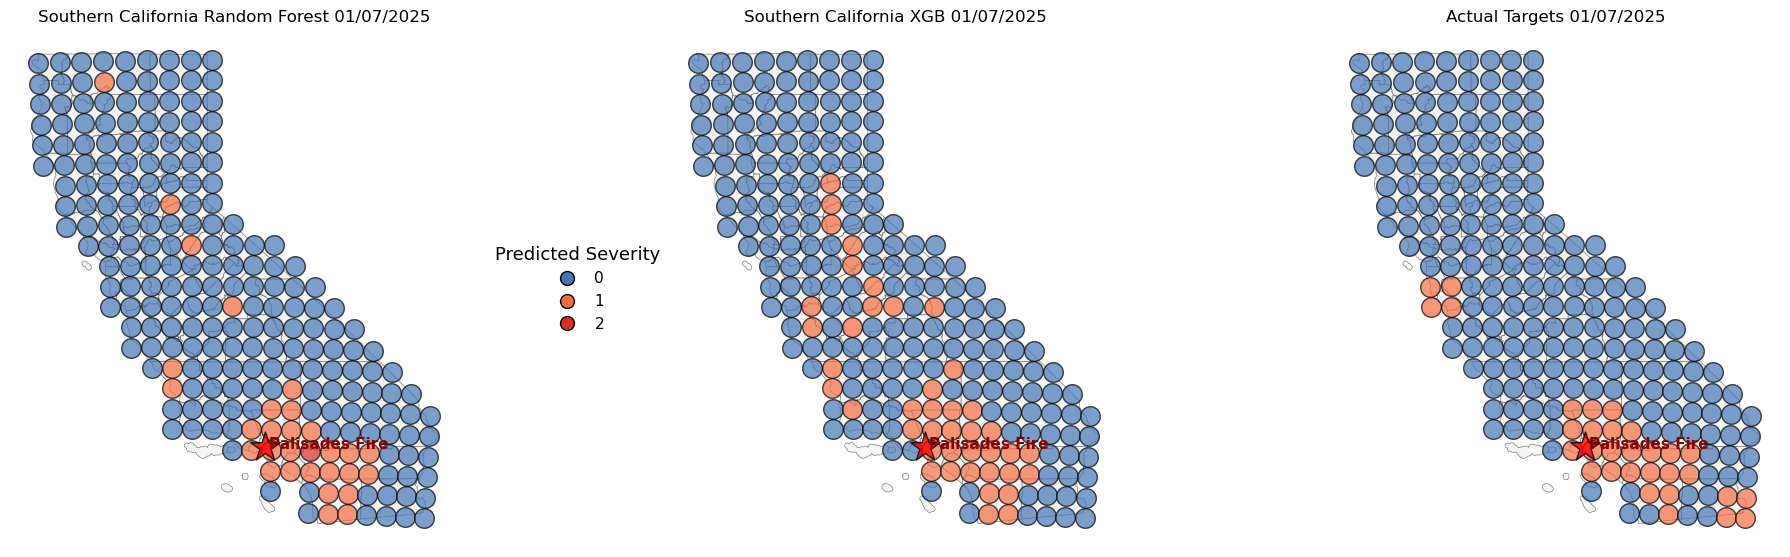

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Actual', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Actual Targets 01/07/2025')

plt.tight_layout()

plt.savefig("../plots/Palisades_predictions_subset.png", dpi=600)

### Actual Targets

### Example Prediction Interpolated

<img src="../data/maps/IDW_RF.jpg" width="600">

## 3. Export File

In [30]:
pal_gdf.to_csv('../data/processed/predictions.csv', index=False)

In [31]:
for c in X.columns:
    print(c)

Burning Index
Energy Release Component
Actual Evapotranspiration
100-hour Dead Fuel Moisture
1000-hour Dead Fuel Moisture
Precipitation
Maximum Relative Humidity
Minimum Relative Humidity
Specific Humidity
Solar Radiation
Daily Minimum Air Temperature
Daily Maximum Air Temperature
Vapor Pressure Deficit
Wind Speed
Standardized Precipitation Index 30-Day
Standardized Precipitation Index 180-Day
Standardized Precipitation Evapotranspiration Index 30-Day
Standardized Precipitation Evapotranspiration Index 90-Day
Standardized Precipitation Evapotranspiration Index 180-Day
Palmer Drought Severity Index
influence_zone
interface_zone
intermix_zone
dominant_province_percent
sum_province_area
sum_section_area
dominant_section_percent
forest_percent
developed_percent
other_percent
shrub_grass_percent
wetlands_percent
elevation_range
elevation_mean
elevation_std
slope_max
slope_range
slope_mean
slope_std
northness_mean
eastness_mean
median_income
road_length_meters
road_density
power_line_meters
